<div style="border-bottom: 4px solid #003366; margin-bottom: 20px; padding-bottom: 10px; display: flex; justify-content: space-between; align-items: center;">
    <div style="flex-grow: 1;">
        <h1 style="color: #003366; font-family: 'Helvetica', sans-serif; margin-bottom: 5px;">MAT2605: Cálculo Científico I</h1>
        <h2 style="color: #555; margin-top: 0; margin-bottom: 10px;">Laboratorio 06: Ecuaciones No Lineales</h2>
        <p style="margin: 2px 0;"><b>Profesores:</b> Thomas F&uuml;hrer y Manuel A. Sánchez | <b>Fecha:</b> 15 de Mayo, 2026</p>
        <p style="margin: 2px 0;"><b>Institución:</b> Facultad de Matemáticas, Pontificia Universidad Católica de Chile</p>
    </div>
    <div style="flex: 0 0 auto; margin-left: 20px;">
        <img src="../source/FacMatematicas-15.png" 
             alt="Logo UC" 
             style="height: 60px; width: auto;">
    </div>

</div>

<div style="border: 1px solid #2980b9; border-left: 8px solid #2980b9; padding: 15px; border-radius: 5px; margin-bottom: 20px;">
    <h3 style="color: #2980b9; margin-top: 0;">🎯 Objetivos de la Sesión</h3>
    <ul>
        <li>1. </li>
    </ul>
</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px; margin-bottom: 20px;">
    <h3 style="color: #2e7d32; margin-top: 0;">👤 Identificación del Estudiante</h3>
    <p style="margin-bottom: 10px; color: #555;">Por favor, completa tus datos antes de comenzar:</p>
    <ul style="list-style-type: none; padding-left: 0; color: #333;">
        <li style="margin-bottom: 5px;"><b>📌 Nombre Completo:</b> _______________________________________</li>
        <li style="margin-bottom: 5px;"><b>📌 Rol / Nº Alumno:</b> _________________________</li>
    </ul>
    <p style="font-size: 0.85em; color: #2e7d32; margin-top: 15px; border-top: 1px solid #a5d6a7; padding-top: 5px;">
        <i>💡 Haz doble clic en esta celda para editarla con tus datos.</i>
    </p>
</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import math

# INTENTO DE CONFIGURACIÓN DE ESTILO (Compatible con versiones viejas y nuevas)
try:
    plt.style.use('seaborn-v0_8-whitegrid') # Nombre nuevo (Matplotlib 3.6+)
except OSError:
    plt.style.use('seaborn-whitegrid')      # Nombre antiguo

plt.rcParams['figure.figsize'] = (10, 6)

print(f"Versión de Numpy: {np.__version__}")
print(f"Estilo usado: {plt.style.context}")

Versión de Numpy: 2.4.4
Estilo usado: <function context at 0x7fbeb0462f00>


<div class="alert-block alert-warning "; style=" border-left: 5px solid #ffc107; padding: 15px; border-radius: 5px;">
    <h2 > </h2>
    <h3 style="color: #d35400; margin-top: 0;">📚 Teoría:</h3>
</div>

In [2]:
def bisection(f, a, b, tol=1e-8, max_iter=100):
    if f(a) * f(b) >= 0:
        return None  # abortar si no se puede asegurar existencia de raiz
    
    for i in range(max_iter):
        c = (a + b) / 2
        if abs(f(c)) < tol or (b - a) / 2 < tol:
            return c
        if f(c) * f(a) < 0:
            b = c
        else:
            a = c
    return (a + b) / 2

In [3]:
def secant(f, x0, x1, tol=1e-8, max_iter=100):
    for i in range(max_iter):
        fx0 = f(x0)
        fx1 = f(x1)
        if abs(fx1 - fx0) < 1e-15: # evitar dividir por "zero"
            return x1
        
        x_next = x1 - fx1 * (x1 - x0) / (fx1 - fx0)
        
        if abs(x_next - x1) < tol:
            return x_next
        x0, x1 = x1, x_next
    return x1

In [4]:
def newton(f, df, x0, tol=1e-8, max_iter=100):
    xn = x0
    for i in range(max_iter):
        fxn = f(xn)
        dfxn = df(xn)
        if abs(dfxn)<1e-15:
            return None # chequear si derivada se anula
        
        xn_next = xn - fxn / dfxn
        
        if abs(xn_next - xn) < tol:
            return xn_next
        xn = xn_next
    return xn

## Ejemplos

### Ejemplo 1: 
$f(x) = x^2-2$

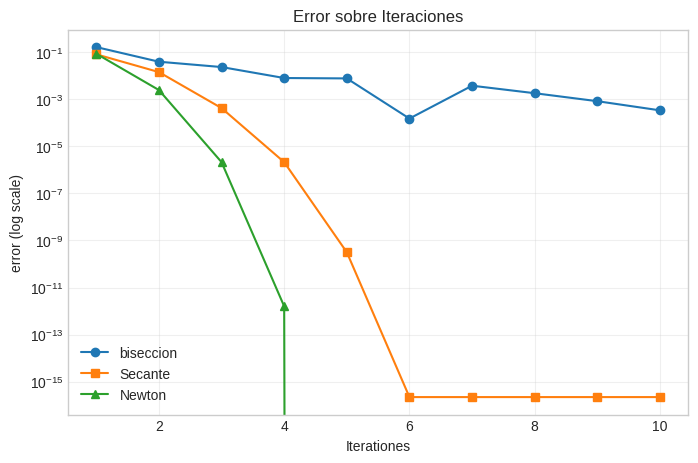

In [9]:
# Funcion: f(x) = x^2 - 2 (raiz es sqrt(2))
func = lambda x: x**2 - 2
dfunc = lambda x: 2*x
root_true = np.sqrt(2)

iterations = range(1, 11)
err_bisect = [abs(bisection(func, 1, 2, max_iter=i) - root_true) for i in iterations]
err_secant = [abs(secant(func, 1, 2, max_iter=i) - root_true) for i in iterations]
err_newton = [abs(newton(func, dfunc, 2, max_iter=i) - root_true) for i in iterations]

# --- PLOT ---
plt.figure(figsize=(8, 5))
plt.semilogy(iterations, err_bisect, 'o-', label='biseccion')
plt.semilogy(iterations, err_secant, 's-', label='Secante')
plt.semilogy(iterations, err_newton, '^-', label='Newton')

plt.title('Error sobre Iteraciones')
plt.xlabel('Iteraciones')
plt.ylabel('error (log scale)')
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend()
plt.show()

### Ejemplo 2
$f(x) = \sqrt[3]{x}$

In [38]:


# funcion: f(x) = x^(1/3)
f = lambda x: math.copysign(abs(x)**(1/3), x)
df = lambda x: (1/3) * (abs(x)**(-2/3))

# met. biseccion
print(f"Bisection resultado: {bisection(f, -0.666, 1)}") 

# met. Secante
print(f"Secant resultado: {secant(f, -0.666, 1)}")

# met. Newton-Rhapson
print(f"Newton resultado: {newton(f, df, 1)}")

Bisection resultado: 5.520880203211526e-09
Secant resultado: 0.7259000205436832
Newton resultado: None


De hecho, met. de Newton ni siquiera converge con $x_0$ cerca de $0$ (que es la ra&iacute;z)

In [13]:
print(f"Newton resultado: {newton(f, df, 0.00001)}")

Newton resultado: None


Para analizar este caso: calculamos $x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)} = -2x_n$

Entonces, para cada valor inicial $x_0\neq 0$ nos alejamos de la ra&iacute;z real.
Nota que $f'(x)$ no est&aacute; definida para $x=0$. 

Podemos estudiar convergencia del m&eacute;todo de bisecci&oacute;n y secante:

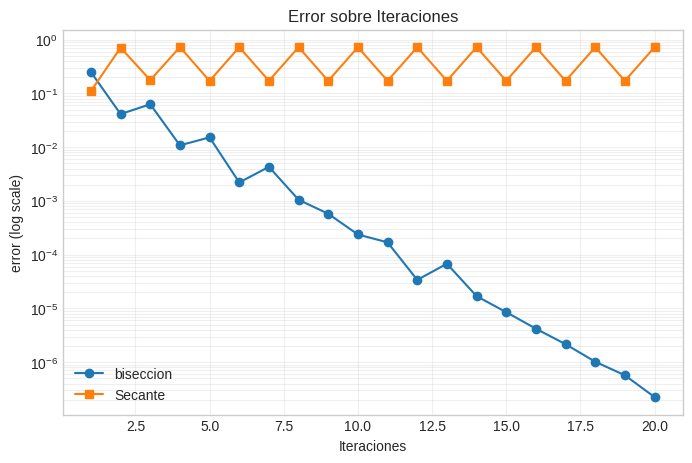

In [42]:
f = lambda x: math.copysign(abs(x)**(1/3), x)
root_true = 0

iterations = range(1, 21)
err_bisect = [abs(bisection(f, -0.666, 1, max_iter=i) - root_true) for i in iterations]
err_secant = [abs(secant(f, -0.666, 1, max_iter=i) - root_true) for i in iterations]

# --- PLOT ---
plt.figure(figsize=(8, 5))
plt.semilogy(iterations, err_bisect, 'o-', label='biseccion')
plt.semilogy(iterations, err_secant, 's-', label='Secante')

plt.title('Error sobre Iteraciones')
plt.xlabel('Iteraciones')
plt.ylabel('error (log scale)')
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend()
plt.show()

---
<div class="alert alert-block alert-success"> 

## Evaluaci&oacute;n:

</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Ejercicio 1:</h3>
    Se anuncia durante el Laboratorio.
</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #6a1b9a; margin: 0; font-size: 1.1em;">
        ✏️ Solución / Desarrollo
    </h3>
    <p style="margin: 5px 0 0 0; font-size: 0.9em; color: #666;">
        <i>Utilice las celdas de código y texto debajo de esta línea para responder. Recuerde comentar su código.</i>
    </p>
</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Ejercicio 2:</h3>
Se anuncia durante el Laboratorio.
</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #6a1b9a; margin: 0; font-size: 1.1em;">
        ✏️ Solución / Desarrollo
    </h3>
    <p style="margin: 5px 0 0 0; font-size: 0.9em; color: #666;">
        <i>Utilice las celdas de código y texto debajo de esta línea para responder. Recuerde comentar su código.</i>
    </p>
</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Ejercicio 3: </h3>
    Se anuncia durante el Laboratorio.
</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #6a1b9a; margin: 0; font-size: 1.1em;">
        ✏️ Solución / Desarrollo
    </h3>
    <p style="margin: 5px 0 0 0; font-size: 0.9em; color: #666;">
        <i>Utilice las celdas de código y texto debajo de esta línea para responder. Recuerde comentar su código.</i>
    </p>
</div>